In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as  sns
plt.style.use("ggplot")
df = pd.read_csv("../processed_data/swiggy_zomato_featured.csv")


In [8]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 62 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   restaurant_id                         8000 non-null   object 
 1   restaurant_name                       8000 non-null   object 
 2   city                                  8000 non-null   object 
 3   locality                              8000 non-null   object 
 4   latitude                              8000 non-null   float64
 5   longitude                             8000 non-null   float64
 6   restaurant_type                       8000 non-null   object 
 7   cuisines                              8000 non-null   object 
 8   top_selling_dish                      8000 non-null   object 
 9   distance_from_city_center_km          8000 non-null   float64
 10  opening_time                          8000 non-null   object 
 11  closing_time     

In [9]:
#Which platform has higher average ratings?
ratings=pd.DataFrame({
    "Platform": ["Swiggy","Zomato"],
    "Average Rating": [
        df["swiggy_rating"].mean(),
        df["zomato_rating"].mean()
    ]
})
ratings

,Platform,Average Rating
0,Swiggy,4.371725
1,Zomato,4.373325


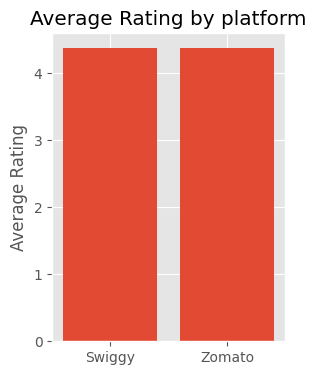

In [16]:
#   Visualization
plt.figure(figsize=(3,4)),
plt.bar(ratings["Platform"], ratings["Average Rating"])
plt.title("Average Rating by platform")
plt.ylabel("Average Rating")
plt.show()


Observation:
the average customer rating for swiggy and zomato is alsmost identical. zomato has a highere marginally hih=gher average  rating by 0.0016 points which is too small.

In [18]:
orders=pd.DataFrame({
    "Platform":["Swiggy", "zomato"],
    "Orders":[
        df["swiggy_estimated_monthly_orders"].sum(),
        df["zomato_estimated_monthly_orders"].sum()
    ]
})
orders

,Platform,Orders
0,Swiggy,2173418
1,zomato,2172529


[]

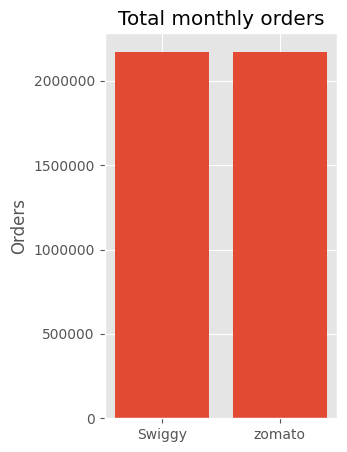

In [26]:
#visulaization
plt.figure(figsize=(3,5))
plt.bar(orders["Platform"] ,orders["Orders"])
plt.title("Total monthly orders")
plt.ylabel("Orders")
plt.ticklabel_format(style='plain', axis='y')

plt.plot()


In [ ]:
#Platform with Higher Revenue
revenue = pd.DataFrame({
    "Platform": ["Swiggy", "Zomato"],
    "Revenue": [
        df["swiggy_estimated_monthly_revenue_inr"].sum(),
        df["zomato_estimated_monthly_revenue_inr"].sum()
    ]
})

revenue

,Platform,Revenue
0,Swiggy,1113071044
1,Zomato,1104465307


Observation:
Swiggy generated an estimated monthly revenue of ₹1,113,071,044, while Zomato generated ₹1,104,465,307. Swiggy's revenue is slightly higher by approximately ₹8.61 million (₹86.1 lakh). Overall, both platforms perform similarly in terms of revenue.

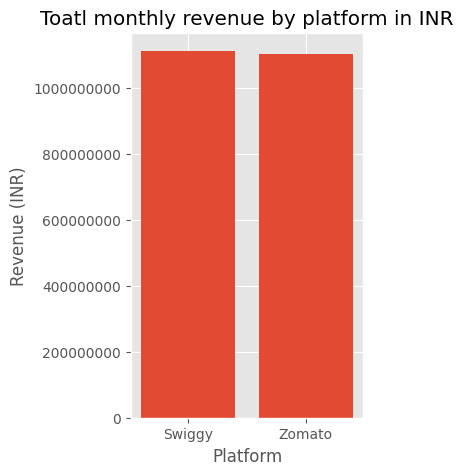

In [32]:
plt.figure(figsize=(3,5))
plt.bar(revenue["Platform"], revenue["Revenue"])
plt.title("Toatl monthly revenue by platform in INR")
plt.xlabel("Platform")
plt.ylabel("Revenue (INR)")
plt.ticklabel_format(style='plain',axis='y')
plt.show()

In [4]:
#platform with higher monthly net Porfit

profit = pd.DataFrame({
    "Platform": ["Swiggy", "Zomato"],
    "Net Profit" : [
     df["swiggy_estimated_net_profit_inr"].sum(),
     df["zomato_estimated_net_profit_inr"].sum(),
    ]
})
profit

,Platform,Net Profit
0,Swiggy,852871059
1,Zomato,845814797


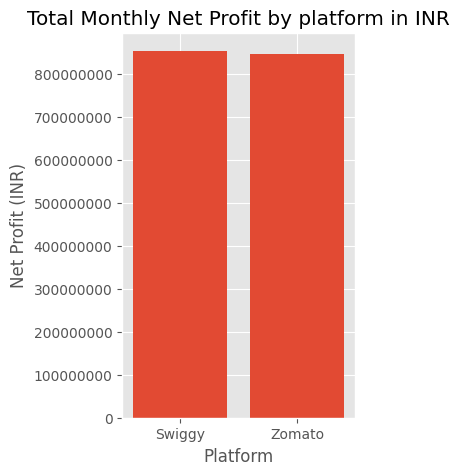

In [7]:
#visulaization of monthly net profit
plt.figure(figsize=(3,5))
plt.bar(profit["Platform"], profit["Net Profit"])
plt.title("Total Monthly Net Profit by platform in INR")
plt.xlabel("Platform")
plt.ylabel("Net Profit (INR)")
plt.ticklabel_format(style='plain',axis='y')
plt.show()


In [9]:
#city generating highest revenue 
city_revenue=(
    df.groupby("city")["total_monthly_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

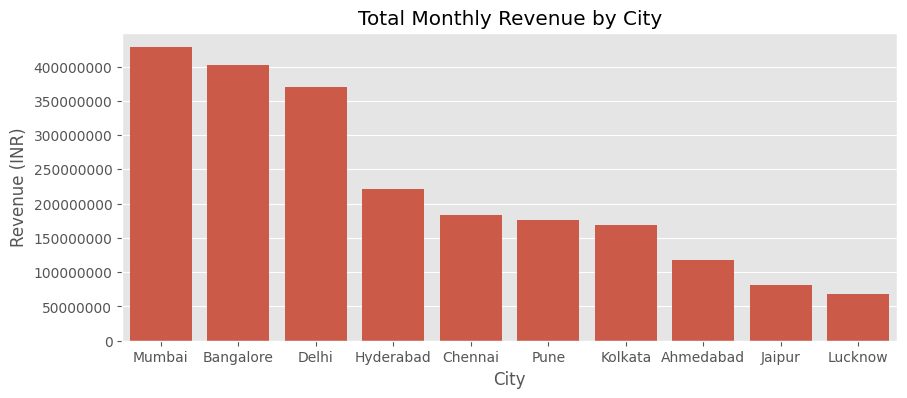

In [12]:
#visualization_of_city_generating_highest_revenue
plt.figure(figsize=(10,4))
sns.barplot(
    data=city_revenue,
    x="city",
    y="total_monthly_revenue"
)
plt.title("Total Monthly Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (INR)")
plt.ticklabel_format(style='plain',axis='y')
plt.show()


Observation:
Mumbai has the highest estimated monthly  revenue, followed by Bangalore and Delhi 